# Steam Games Data Analysis

## Activity Description
Steam Games: Player Engagement, Revenue Patterns & Market Trends Analysis

## Artifact Description
A Jupyter notebook containing:
- Complete data analysis workflow
- Multiple visualizations
- Statistical analysis and key insights

## Why This Activity
- Practices realistic data analyst workflows
- Strengthens pandas grouping/aggregation and matplotlib customization skills
- Produces insights that feel like a real gaming-industry report

## Learning Objectives
1. Create new features and use pandas grouping/aggregation to answer business questions
2. Design and customize multiple matplotlib chart types to clearly show trends
3. Build and interpret meaningful metrics

## Time Estimate: 4 hours total:
- 0.5 hour: Load & explore
- 1 hour: Clean + create new features
- 2 hours: Analysis & visualizations
- 0.5 hour: Documentation and refinement

## Step 1: Import Libraries and Load Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load the data from CSV file
df = pd.read_csv('steam_games.csv')

## Step 2: Explore the Data

In [4]:
print("Dataset shape:", df.shape)
print("\nData types and non-null counts:")

Dataset shape: (50, 9)

Data types and non-null counts:


In [5]:
print(df.info())
print("\nBasic statistics:")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_name        50 non-null     object 
 1   release_year     50 non-null     int64  
 2   developer        50 non-null     object 
 3   primary_genre    50 non-null     object 
 4   price_usd        50 non-null     float64
 5   current_players  50 non-null     int64  
 6   peak_today       50 non-null     int64  
 7   user_rating      50 non-null     float64
 8   num_reviews      50 non-null     int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 3.6+ KB
None

Basic statistics:


In [6]:
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
       release_year  price_usd  current_players    peak_today  user_rating  \
count     50.000000   50.00000     5.000000e+01  5.000000e+01    50.000000   
mean    2019.020000   21.83420     9.273010e+04  1.256293e+05    86.800000   
std        4.871785   23.42861     1.763272e+05  2.194302e+05     7.992343   
min     2007.000000    0.00000     3.058700e+04  3.365300e+04    58.000000   
25%     2015.000000    0.00000     3.438950e+04  4.196900e+04    83.000000   
50%     2019.000000   17.49000     4.771200e+04  5.993300e+04    88.000000   
75%     2024.000000   39.99000     6.724100e+04  9.148375e+04    92.000000   
max     2025.000000   69.99000     1.142703e+06  1.325689e+06    97.000000   

        num_reviews  
count  5.000000e+01  
mean   3.518688e+05  
std    5.004623e+05  
min    5.000000e+03  
25%    6.250000e+04  
50%    2.000000e+05  
75%    5.000000e+05  
max    2.500000e+06  


In [7]:
print("\nUnique developers:", df['developer'].nunique())
print("Unique genres:", df['primary_genre'].nunique())
print("Games released per year:")
print(df['release_year'].value_counts().sort_index())


Unique developers: 45
Unique genres: 10
Games released per year:
release_year
2007     1
2011     1
2012     2
2013     4
2014     2
2015     4
2016     6
2017     2
2018     2
2019     2
2020     1
2021     1
2022     3
2023     3
2024    11
2025     5
Name: count, dtype: int64


## Step 3: Data Cleaning and Feature Engineering

### 3.1 Confirm no missing values

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
game_name          0
release_year       0
developer          0
primary_genre      0
price_usd          0
current_players    0
peak_today         0
user_rating        0
num_reviews        0
dtype: int64


### 3.2 Create price tiers

In [ ]:
df['price_tier'] = pd.cut(df['price_usd'], bins=[-0.01, 0, 10, 30, 100], labels=['Free', 'Low', 'Medium', 'Premium'])

### 3.3 Player retention ratio (current vs peak)


In [ ]:
df['retention_ratio'] = (df['current_players'] / df['peak_today'] * 100).round(1)

### 3.4 Estimated daily revenue

In [ ]:
df['est_daily_revenue'] = df['current_players'] * df['price_usd']

### 3.5 Popularity score

In [ ]:
df['popularity_score'] = df['current_players'] * (df['user_rating'] / 100)

### 3.6 Age of game in years

In [ ]:
current_year = 2026
df['game_age'] = current_year - df['release_year']

## Step 4: Core Analysis & Visualizations

### 4.1 Genre performance comparison (total players and revenue)

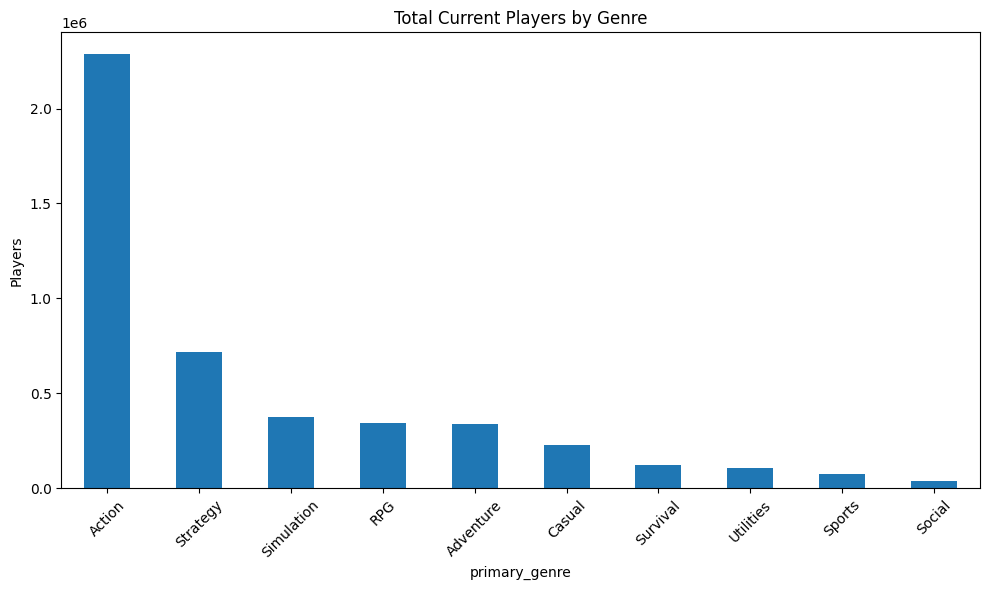

In [ ]:
genre_stats = df.groupby('primary_genre').agg(total_games=('game_name', 'count'),total_current_players=('current_players', 'sum'),total_est_revenue=('est_daily_revenue', 'sum'),avg_rating=('user_rating', 'mean')).round(0)

plt.figure(figsize=(10, 6))
genre_stats['total_current_players'].sort_values(ascending=False).plot(kind='bar')
plt.title('Total Current Players by Genre')
plt.ylabel('Players')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Release year trends

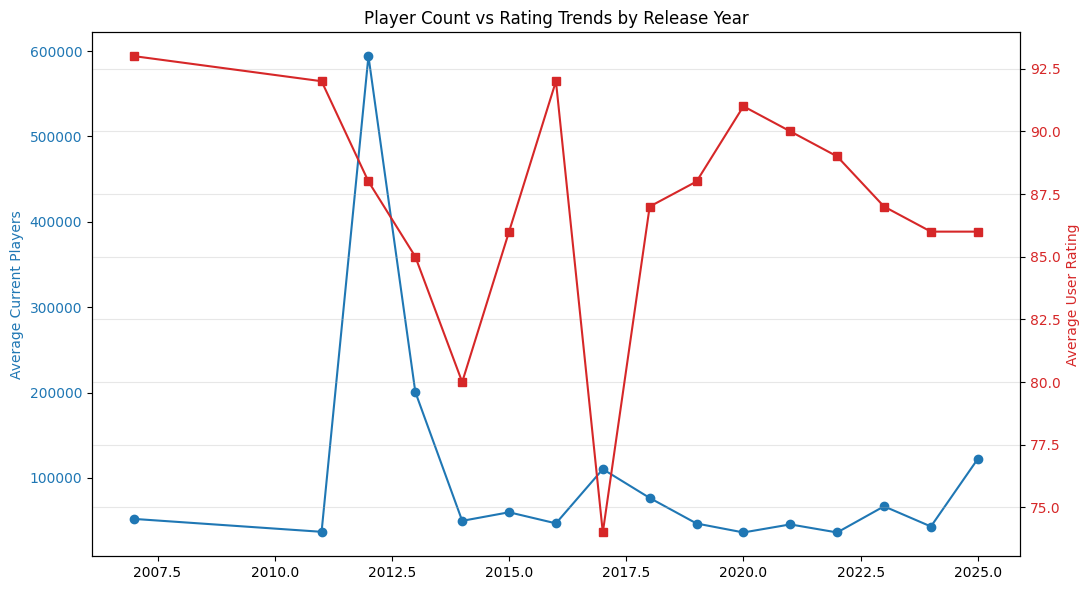

In [ ]:
year_trends = df.groupby('release_year').agg(games_released=('game_name', 'count'), avg_players=('current_players', 'mean'), avg_rating=('user_rating', 'mean')).round(0)

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(year_trends.index, year_trends['avg_players'], color='tab:blue', marker='o')
ax1.set_ylabel('Average Current Players', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(year_trends.index, year_trends['avg_rating'], color='tab:red', marker='s')
ax2.set_ylabel('Average User Rating', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Player Count vs Rating Trends by Release Year')
plt.xlabel('Release Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Price vs Player relationship

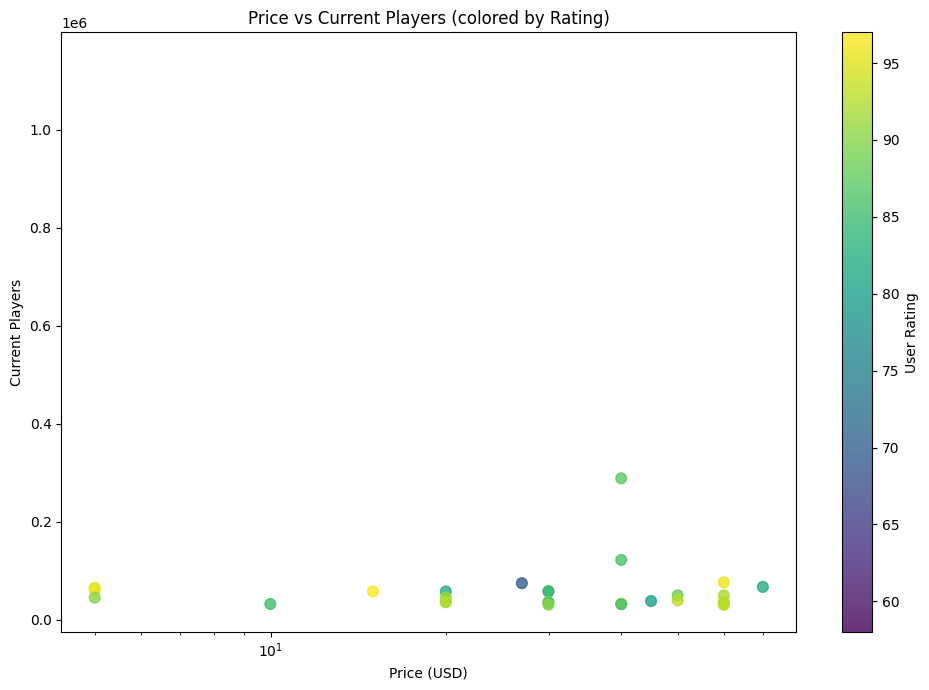

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['price_usd'], df['current_players'], c=df['user_rating'], cmap='viridis', s=60, alpha=0.8)
plt.colorbar(scatter, label='User Rating')
plt.title('Price vs Current Players (colored by Rating)')
plt.xlabel('Price (USD)')
plt.ylabel('Current Players')
plt.xscale('log')
plt.tight_layout()
plt.show()

### 4.4 Market share by genre

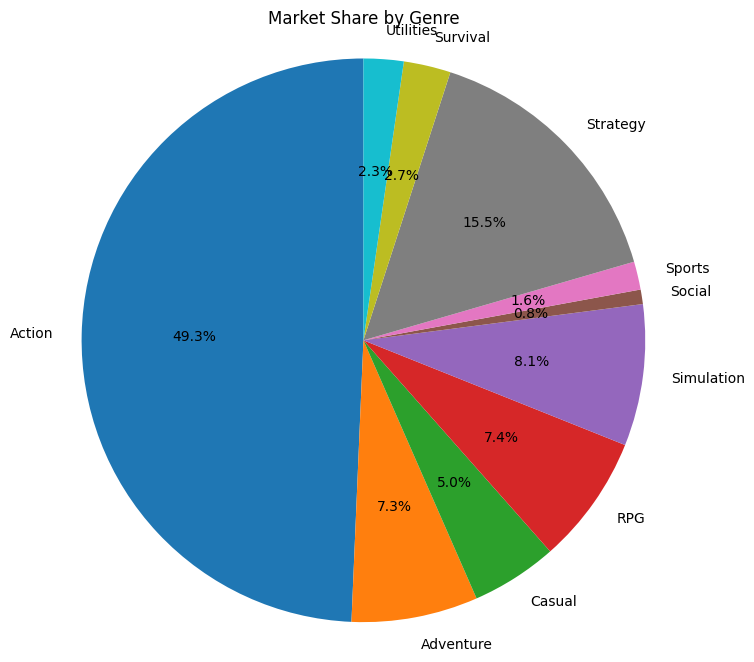

In [37]:
plt.figure(figsize=(8, 8))
plt.pie(genre_stats['total_current_players'], labels=genre_stats.index, autopct='%1.1f%%',startangle=90)
plt.title('Market Share by Genre')
plt.axis('equal')
plt.show()

### 4.5 Top 10 games by estimated revenue

In [21]:
top_revenue = df.nlargest(10, 'est_daily_revenue')[['game_name', 'est_daily_revenue', 'price_usd', 'current_players']]
print(top_revenue)

                game_name  est_daily_revenue  price_usd  current_players
2             ARC Raiders        11545552.89      39.99           288711
5                    Rust         4890976.95      39.99           122305
13          Battlefield 6         4703467.98      69.99            67202
9          Baldurs Gate 3         4588515.12      59.99            76488
24    Football Manager 26         2993501.00      59.99            49900
23                   DayZ         2495550.79      49.99            49921
35         Cyberpunk 2077         2160599.84      59.99            36016
37             ELDEN RING         2058616.84      59.99            34316
38  Red Dead Redemption 2         2057716.99      59.99            34301
10        EA SPORTS FC 26         2019762.00      27.00            74806


## Step 5: Additional Insights & Statistical Summaries

### 5.1 How ratings are spread out

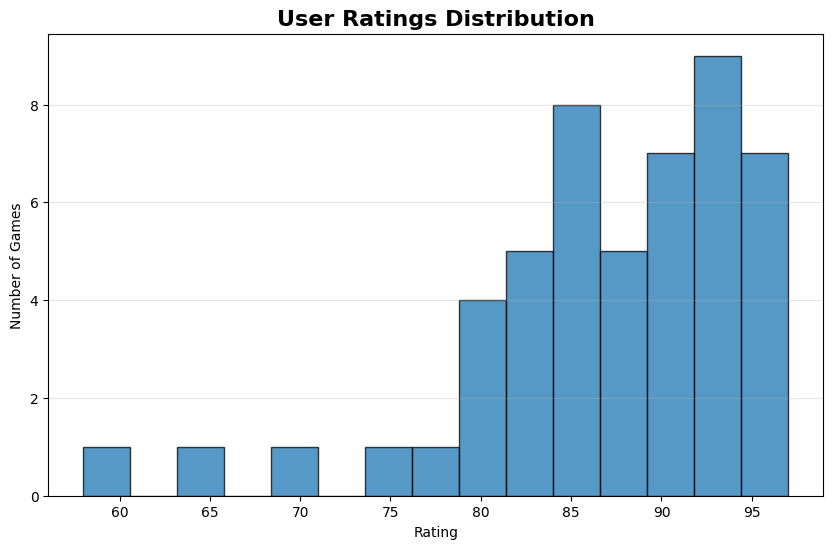

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(df['user_rating'], bins=15, color='#1f77b4', edgecolor='black', alpha=0.75)
plt.title("User Ratings Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Number of Games")
plt.grid(axis='y', alpha=0.3)
plt.show()

### 5.2 Which genres are expensive?

<Figure size 1200x700 with 0 Axes>

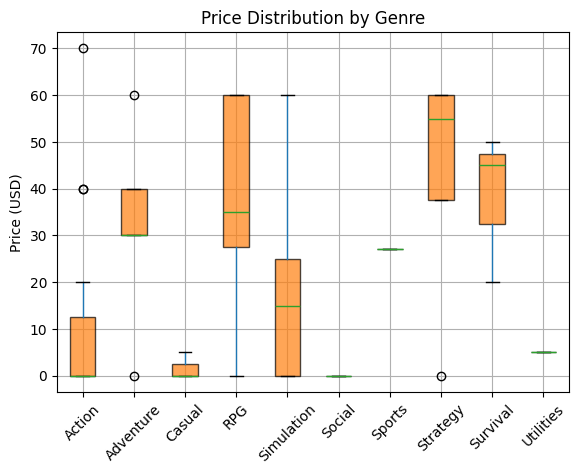

In [ ]:
plt.figure(figsize=(12, 7))
df.boxplot(column='price_usd', by='primary_genre', patch_artist=True, boxprops=dict(facecolor='#ff7f0e', alpha=0.7))
plt.title("Price Distribution by Genre")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.show()

### 5.3 Players vs Reviews

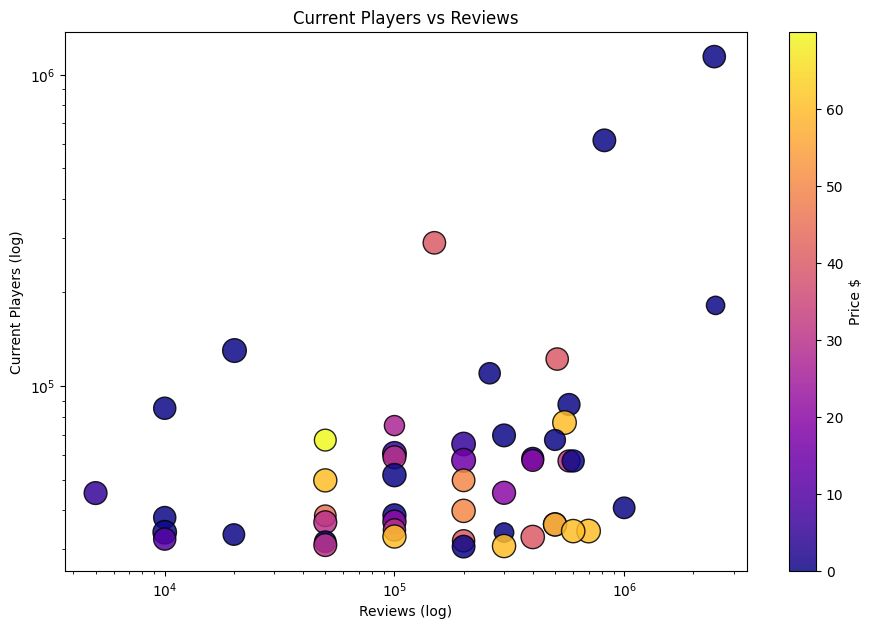

In [38]:
plt.figure(figsize=(11, 7))
plt.scatter(df['num_reviews'], df['current_players'], s=df['user_rating']*3, c=df['price_usd'], cmap='plasma', alpha=0.85, edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.title("Current Players vs Reviews")
plt.xlabel("Reviews (log)")
plt.ylabel("Current Players (log)")
plt.colorbar(label='Price $')
plt.show()

### 5.4 Top developers

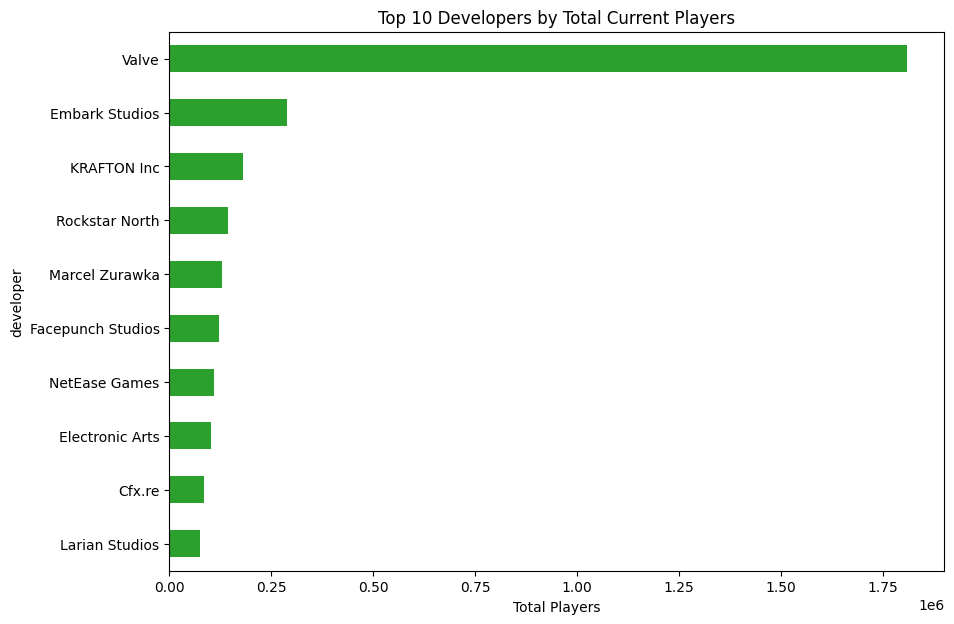

In [29]:
top_devs = df.groupby('developer')['current_players'].sum().nlargest(10)
plt.figure(figsize=(10, 7))
top_devs.sort_values().plot(kind='barh', color='#2ca02c')
plt.title("Top 10 Developers by Total Current Players")
plt.xlabel("Total Players")
plt.show()

### 5.5 Retention by price tier

C:\Users\Thanh Vu\AppData\Local\Temp\ipykernel_12436\423821145.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_tier')['retention_ratio'].mean().plot(kind='bar', color=['#d62728','#9467bd','#8c564b','#e377c2'])


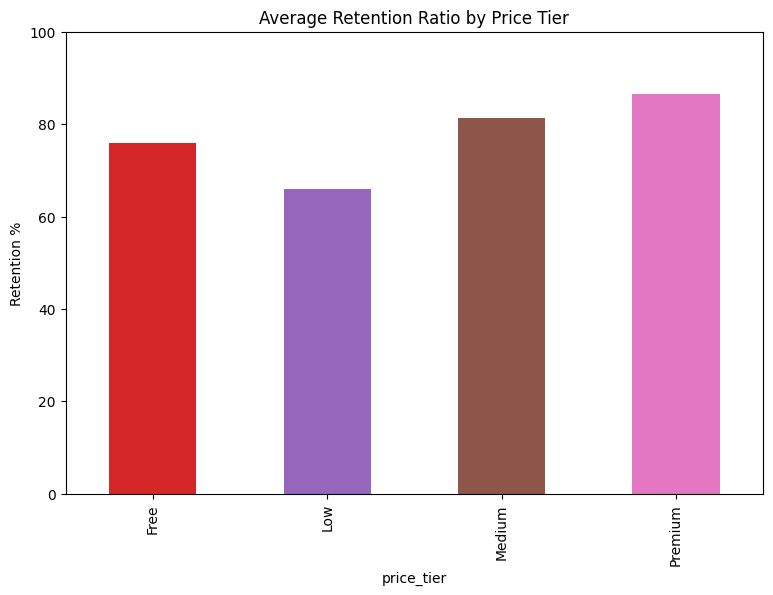

In [30]:
plt.figure(figsize=(9, 6))
df.groupby('price_tier')['retention_ratio'].mean().plot(kind='bar', color=['#d62728','#9467bd','#8c564b','#e377c2'])
plt.title("Average Retention Ratio by Price Tier")
plt.ylabel("Retention %")
plt.ylim(0, 100)
plt.show()

### 5.6 Correlation heatmap

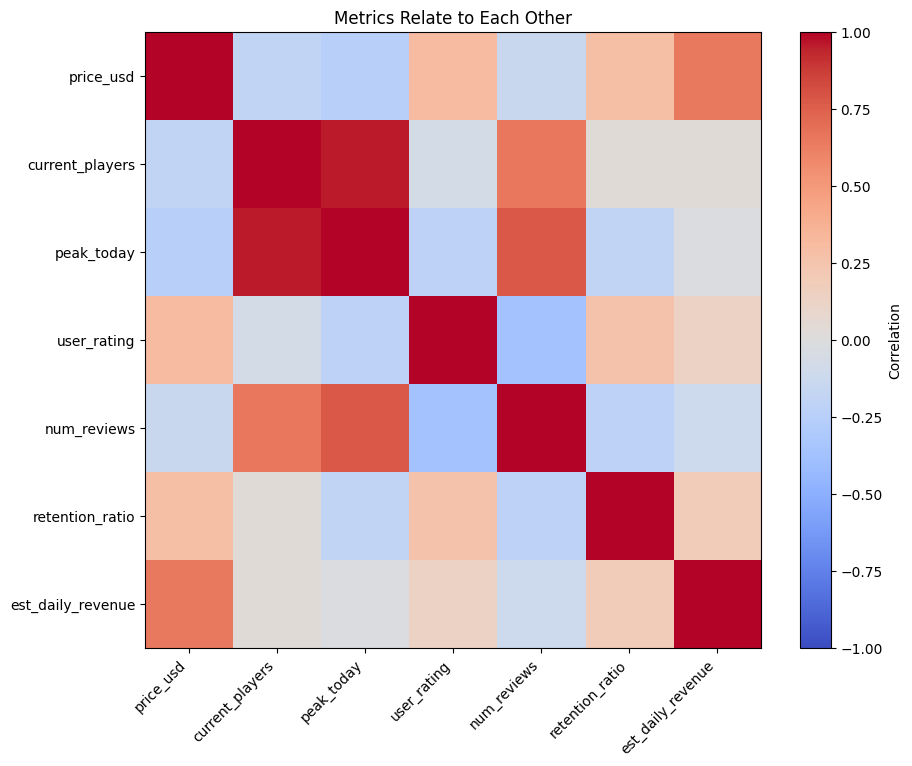

In [32]:
corr = df[['price_usd', 'current_players', 'peak_today', 'user_rating', 'num_reviews', 'retention_ratio', 'est_daily_revenue']].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Metrics Relate to Each Other")
plt.show()

## Step 6: Summary Statistics

In [33]:
most_common_genre = df['primary_genre'].value_counts().idxmax()
print(f"Most common genre: {most_common_genre}")

Most common genre: Action


In [34]:
average_price = df['price_usd'].mean()
print(f"Average game price: ${average_price:.2f}")

Average game price: $21.83


In [35]:
highest_rated = df.loc[df['user_rating'].idxmax()]
print(f"Highest rated game: {highest_rated['game_name']} with rating {highest_rated['user_rating']}")

Highest rated game: Bongo Cat with rating 97.0


In [36]:
most_players = df.loc[df['current_players'].idxmax()]
print(f"Game with most current players: {most_players['game_name']} with {most_players['current_players']:,} players")

Game with most current players: Counter-Strike 2 with 1,142,703 players


## Step 7: Save Processed Data

In [ ]:
df.to_csv('steam_games_processed.csv', index=False)